In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

STRATEGIES = ["no_upgrades", "grinder", "sign", "combined"]

COLORS = {
    "no_upgrades": "#808080",
    "grinder": "#8B5A2B",
    "sign": "#2E8B57",
    "combined": "#D4A72C",
}

LABELS = {
    "no_upgrades": "No Upgrades",
    "grinder": "Grinder Only",
    "sign": "Sign Only",
    "combined": "Combined",
}

PRODUCT_NAMES = {
    1: "House Coffee",
    2: "Cold Brew",
    3: "Vanilla Latte",
    4: "Matcha Latte",
}


def load_run(transaction_file, day_file, upgrade_file, run):
    transactions = pd.read_csv(transaction_file)
    days = pd.read_csv(day_file)
    upgrades = pd.read_csv(upgrade_file)

    transactions["run"] = run
    days["run"] = run
    upgrades["run"] = run

    if "profit" not in transactions.columns:
        transactions["profit"] = (
            transactions["sale_price"] - transactions["unit_cost"]
        )

    if "product" not in transactions.columns:
        transactions["product"] = transactions["product_id"].map(PRODUCT_NAMES)

    return transactions, days, upgrades


files = {
    "no_upgrades": (
        "transactions.csv",
        "game_days.csv",
        "upgrade_purchases.csv",
    ),
    "grinder": (
        "grinder_transactions.csv",
        "grinder_game_days.csv",
        "grinder_upgrade_purchases.csv",
    ),
    "sign": (
        "sign_transactions.csv",
        "sign_game_days.csv",
        "sign_upgrade_purchases.csv",
    ),
    "combined": (
        "combined_transactions.csv",
        "combined_game_days.csv",
        "combined_upgrade_purchases.csv",
    ),
}

transaction_frames = []
day_frames = []
upgrade_frames = []

for run, run_files in files.items():
    transactions, days, upgrades = load_run(*run_files, run)
    transaction_frames.append(transactions)
    day_frames.append(days)
    upgrade_frames.append(upgrades)

all_transactions = pd.concat(transaction_frames, ignore_index=True)
all_days = pd.concat(day_frames, ignore_index=True)
all_upgrades = pd.concat(upgrade_frames, ignore_index=True)

daily_profit = (
    all_transactions.groupby(["run", "day_id"], as_index=False)["profit"]
    .sum()
    .sort_values(["run", "day_id"])
)

print(f"Transactions loaded: {len(all_transactions)}")
print(f"Game days loaded: {len(all_days)}")
print(f"Upgrade purchases loaded: {len(all_upgrades)}")


Transactions loaded: 799
Game days loaded: 40
Upgrade purchases loaded: 20


## Daily Profit by Strategy

This chart compares operating profit across the 10 game days for each upgrade strategy.

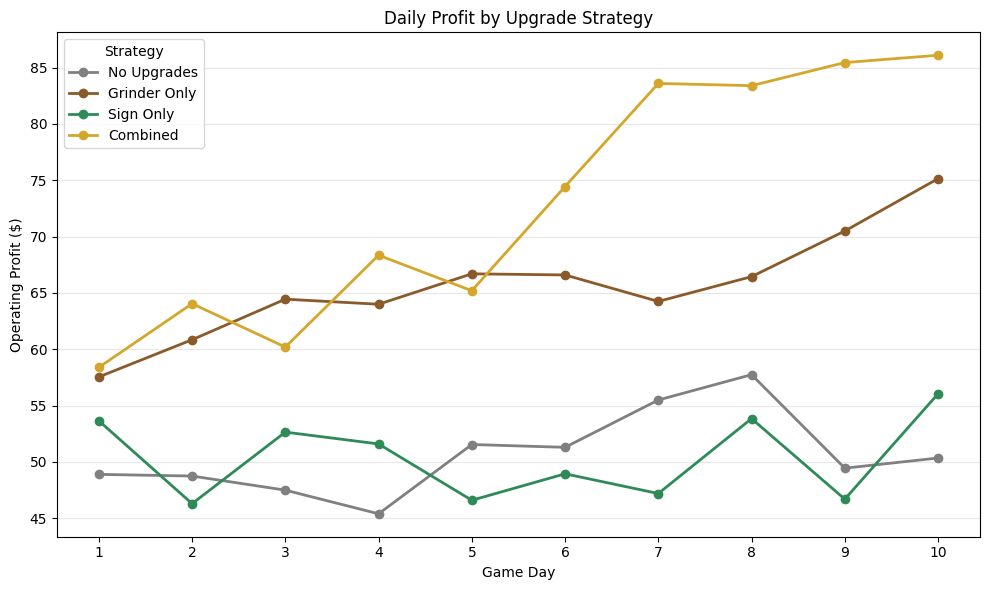

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

for run in STRATEGIES:
    run_data = daily_profit[daily_profit["run"] == run]
    ax.plot(
        run_data["day_id"],
        run_data["profit"],
        marker="o",
        linewidth=2,
        color=COLORS[run],
        label=LABELS[run],
    )

ax.set_title("Daily Profit by Upgrade Strategy")
ax.set_xlabel("Game Day")
ax.set_ylabel("Operating Profit ($)")
ax.set_xticks(range(1, 11))
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Strategy")
plt.tight_layout()
plt.show()


## Completion Rate by Strategy

This chart compares the percentage of arriving customers whose orders were completed.

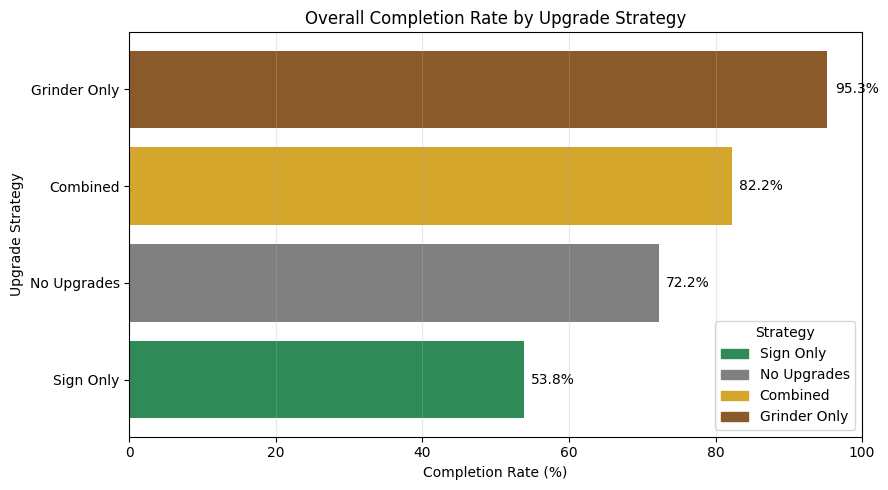

In [3]:
completion = (
    all_days.groupby("run")[["orders_completed", "customers_arrived"]]
    .sum()
    .assign(
        completion_rate=lambda data:
        data["orders_completed"] / data["customers_arrived"] * 100
    )
    .sort_values("completion_rate", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    [LABELS[run] for run in completion.index],
    completion["completion_rate"],
    color=[COLORS[run] for run in completion.index],
)

ax.set_title("Overall Completion Rate by Upgrade Strategy")
ax.set_xlabel("Completion Rate (%)")
ax.set_ylabel("Upgrade Strategy")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(completion["completion_rate"]):
    ax.text(value + 1, index, f"{value:.1f}%", va="center")

legend_handles = [
    Patch(color=COLORS[run], label=LABELS[run])
    for run in completion.index
]
ax.legend(handles=legend_handles, title="Strategy", loc="lower right")
plt.tight_layout()
plt.show()


## Customer Volume vs Completion Rate

This chart shows the tradeoff between attracting more customers and successfully completing their orders.

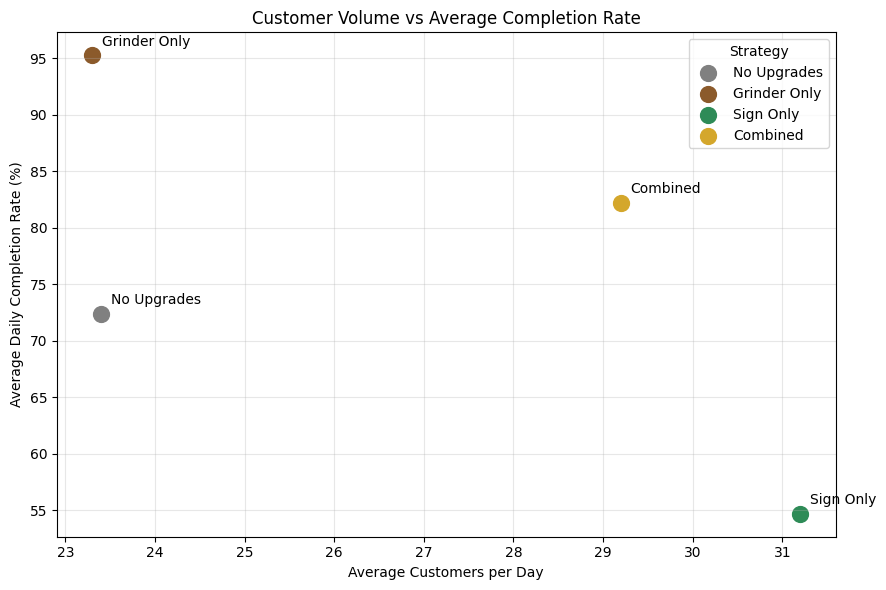

In [4]:
daily_performance = all_days.copy()
daily_performance["completion_rate"] = (
    daily_performance["orders_completed"]
    / daily_performance["customers_arrived"]
    * 100
)

strategy_performance = daily_performance.groupby("run").agg(
    avg_customers_per_day=("customers_arrived", "mean"),
    avg_completion_rate=("completion_rate", "mean"),
)

fig, ax = plt.subplots(figsize=(9, 6))

for run in STRATEGIES:
    point = strategy_performance.loc[run]
    ax.scatter(
        point["avg_customers_per_day"],
        point["avg_completion_rate"],
        s=130,
        color=COLORS[run],
        label=LABELS[run],
    )
    ax.annotate(
        LABELS[run],
        (
            point["avg_customers_per_day"],
            point["avg_completion_rate"],
        ),
        xytext=(7, 7),
        textcoords="offset points",
    )

ax.set_title("Customer Volume vs Average Completion Rate")
ax.set_xlabel("Average Customers per Day")
ax.set_ylabel("Average Daily Completion Rate (%)")
ax.grid(alpha=0.3)
ax.legend(title="Strategy")
plt.tight_layout()
plt.show()


## Average Wait Time by Product and Strategy

This chart compares how each strategy affected customer wait times for each drink.

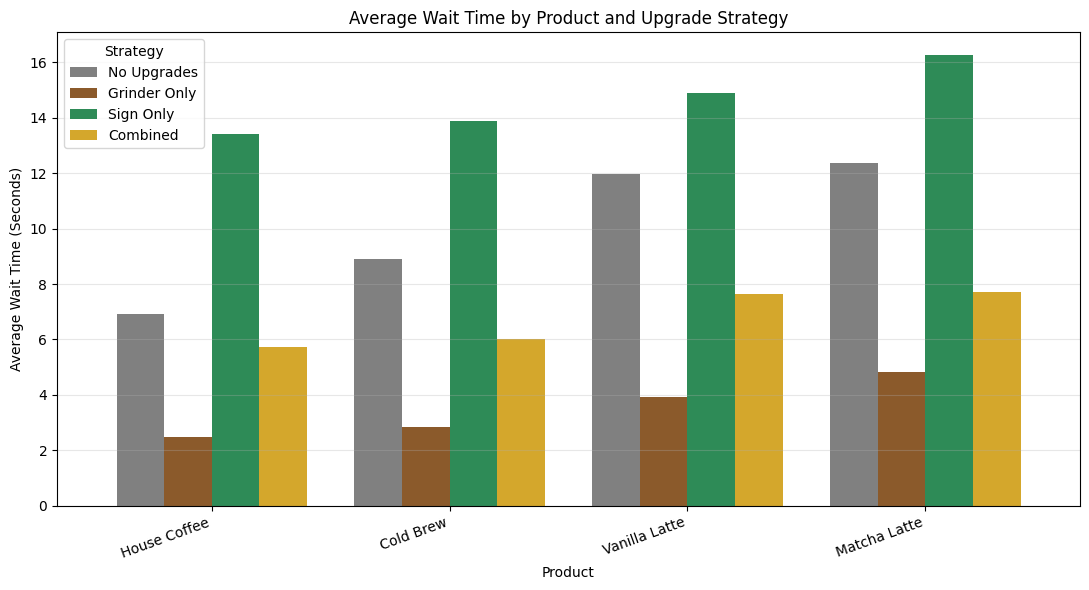

In [5]:
product_order = [
    "House Coffee",
    "Cold Brew",
    "Vanilla Latte",
    "Matcha Latte",
]

wait_by_product = (
    all_transactions.groupby(["product", "run"])["wait_seconds"]
    .mean()
    .unstack("run")
    .reindex(index=product_order, columns=STRATEGIES)
)

fig, ax = plt.subplots(figsize=(11, 6))
wait_by_product.plot(
    kind="bar",
    ax=ax,
    color=[COLORS[run] for run in STRATEGIES],
    width=0.8,
)

ax.set_title("Average Wait Time by Product and Upgrade Strategy")
ax.set_xlabel("Product")
ax.set_ylabel("Average Wait Time (Seconds)")
ax.set_xticklabels(product_order, rotation=20, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.legend(
    [LABELS[run] for run in STRATEGIES],
    title="Strategy",
)
plt.tight_layout()
plt.show()


## Combined Strategy Profit and Upgrade Events

This chart connects changes in daily profit with the timing of grinder and sign purchases.

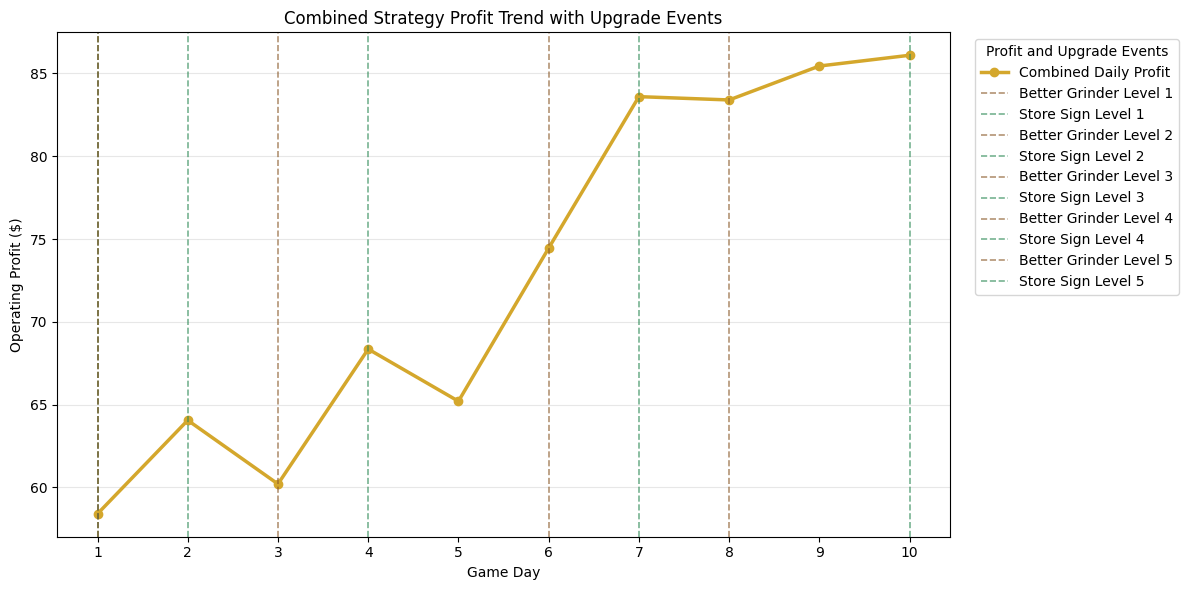

In [6]:
combined_profit = daily_profit[
    daily_profit["run"] == "combined"
].copy()

combined_upgrades = all_upgrades[
    all_upgrades["run"] == "combined"
].sort_values(["day_id", "purchase_id"])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    combined_profit["day_id"],
    combined_profit["profit"],
    marker="o",
    linewidth=2.5,
    color=COLORS["combined"],
    label="Combined Daily Profit",
)

upgrade_colors = {
    "Better Grinder": COLORS["grinder"],
    "Store Sign": COLORS["sign"],
}

for _, purchase in combined_upgrades.iterrows():
    event_label = f"{purchase['upgrade_name']} Level {int(purchase['level'])}"
    ax.axvline(
        purchase["day_id"],
        color=upgrade_colors[purchase["upgrade_name"]],
        linestyle="--",
        linewidth=1.2,
        alpha=0.65,
        label=event_label,
    )

ax.set_title("Combined Strategy Profit Trend with Upgrade Events")
ax.set_xlabel("Game Day")
ax.set_ylabel("Operating Profit ($)")
ax.set_xticks(range(1, 11))
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Profit and Upgrade Events", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Written Findings

- **Highest total operating profit:** The combined strategy produced the highest 10-day operating profit at **$729.20**. Grinder-only followed at **$656.50**, while no upgrades and sign-only produced **$506.45** and **$503.55**, respectively. These figures measure profit from completed drink sales before subtracting upgrade purchases.

- **The sign increased demand but not capacity:** Sign-only attracted **312 customers**, compared with **234** during the no-upgrade run. However, it completed only **168 orders** and had a **53.8% overall completion rate**. The no-upgrade strategy completed **169 orders** with a **72.2% completion rate**. More traffic did not lead to more completed sales because preparation capacity remained the bottleneck.

- **The grinder improved service performance:** Grinder-only completed **222 of 233 orders**, giving it the highest completion rate at **95.3%**. Its average wait time was **3.04 seconds**, compared with **8.93 seconds** for no upgrades and **14.14 seconds** for sign-only. The product comparison also shows lower grinder wait times across every drink, including the slower latte products.

- **The combined strategy converted added demand into sales:** Combining both upgrades completed **240 orders**, the highest total of any strategy, and generated **$729.20** in operating profit. The grinder provided enough additional preparation capacity to benefit from the sign's higher customer volume. The combined strategy still had a lower completion rate than grinder-only, **82.2% versus 95.3%**, because demand increased faster than service capacity.

- **Dataset limitation:** Each strategy was tested for only **10 game days**, and customer arrivals and product selections contain randomness. The differences are meaningful within these runs, but more repeated trials would be needed to separate consistent upgrade effects from random variation. Additionaly, there are only 2 upgrades at the moment for customer arrivals and prep time but adding more varied upgrades with different effects would could complicate things rapidly.
